<div align="center">

# Machine Learning
## Regresión Logistica
### Solución Parcial
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 17 de Abril del 2026

<br><br><br><br><br><br><br><br><br><br>

---

## **Resumen**
<p style="text-align: justify">
Este documento presenta el desarrollo completo de un modelo de <b>Machine Learning</b> basado en <b>Regresión Logística Multinomial</b>, aplicado al dataset <i>Obesity Levels</i>, cuyo objetivo es clasificar el nivel de obesidad de una persona en una de siete categorías posibles. Para ello, se realizó un proceso estructurado que incluyó la exploración inicial del dataset, verificación de valores nulos y duplicados, y la preparación de variables numéricas y categóricas. Posteriormente, se aplicaron técnicas de preprocesamiento como <b>OneHotEncoding</b> para la codificación de variables categóricas y <b>StandardScaler</b> para el escalado de variables numéricas, con el fin de garantizar un entrenamiento estable del modelo.
</p>

<p style="text-align: justify">
Además, se evaluó la distribución de clases para identificar un posible desbalance en la variable objetivo, determinando que la base se encontraba relativamente balanceada y por lo tanto no fue necesario aplicar técnicas de oversampling como SMOTE. También se realizó un análisis de correlación para detectar posibles variables altamente correlacionadas, con el propósito de reducir redundancia y mejorar la interpretabilidad del modelo. Finalmente, se entrenó el modelo comparando distintos solvers de optimización y diferentes valores del parámetro de regularización <b>C</b>, seleccionando la combinación más adecuada según su rendimiento.
</p>

<p style="text-align: justify">
Como resultado, el modelo final alcanzó un desempeño destacado con un <b>accuracy aproximado del 94.42%</b>, acompañado de una matriz de confusión y métricas de clasificación (precision, recall y f1-score) que permitieron identificar las clases con mejor predicción y aquellas con mayor confusión, especialmente en niveles intermedios de sobrepeso. En conclusión, este trabajo evidencia la utilidad de la regresión logística multinomial como método eficiente y confiable para problemas de clasificación multiclase, resaltando además la importancia del preprocesamiento y la selección adecuada de hiperparámetros para maximizar el rendimiento del modelo.
</p>

</div>

# Sección 1 — Selección del Dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================
# 1. Cargar archivo Excel
# ============================
ruta = "../Bases/Data.xlsx"
df = pd.read_excel(ruta)



# SECCIÓN 2 — Limpieza y Preprocesamiento

In [2]:
# ============================
# 2. Arreglar encabezados raros del archivo
# ============================
years = df.iloc[0].tolist()
months = df.iloc[1].tolist()

new_cols = []
for i, col in enumerate(df.columns):
    if i == 0:
        new_cols.append("col0")
    elif i == 1:
        new_cols.append("TIPO")
    elif i == 2:
        new_cols.append("CUENTA_CONTRATO")
    elif pd.notna(years[i]) and pd.notna(months[i]):
        new_cols.append(f"consumo_{int(years[i])}_{int(months[i]):02d}")
    else:
        new_cols.append(f"col_{i}")

df.columns = new_cols

# eliminar filas basura del inicio
df = df.drop(index=[0,1,2]).reset_index(drop=True)

# ============================
# 3. Convertir columnas consumo a numéricas
# ============================
consumo_cols = [c for c in df.columns if c.startswith("consumo_")]

for c in consumo_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [3]:
# ============================
# 4. Crear variable objetivo (Target)
# ============================
# 1 = ATM REMOTO
# 0 = OFICINA
df["target"] = (df["TIPO"] == "ATM REMOTO").astype(int)

print("Distribución de clases:")
print(df["target"].value_counts())

# ============================
# 5. Selección de variables (X e y)
# ============================
X = df[consumo_cols]
y = df["target"]

# reemplazar NaN por promedio (por si hay datos vacíos)
X = X.fillna(X.mean())

# ============================
# 6. División Train / Test
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ============================
# 7. Escalamiento (IMPORTANTE en Regresión Logística)
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 8. Entrenamiento Modelo Regresión Logística
# ============================
modelo = LogisticRegression()
modelo.fit(X_train_scaled, y_train)

# ============================
# 9. Predicciones
# ============================
y_pred = modelo.predict(X_test_scaled)

# ============================
# 10. Evaluación del Modelo
# ============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# ============================
# 11. Probabilidades
# ============================
y_prob = modelo.predict_proba(X_test_scaled)

print("\nEjemplo probabilidades (primeros 5):")
print(y_prob[:5])

Distribución de clases:
target
0    228
1    139
Name: count, dtype: int64

Accuracy: 0.8288288288288288

Matriz de Confusión:
 [[61  8]
 [11 31]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87        69
           1       0.79      0.74      0.77        42

    accuracy                           0.83       111
   macro avg       0.82      0.81      0.82       111
weighted avg       0.83      0.83      0.83       111


Ejemplo probabilidades (primeros 5):
[[0.3540527  0.6459473 ]
 [0.52200588 0.47799412]
 [0.12801704 0.87198296]
 [0.2449209  0.7550791 ]
 [0.31889571 0.68110429]]


### Codificación categórica + escalado numérico:

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# SECCIÓN 3 — Desbalance de Clases

## 3.1 Visualizar distribución

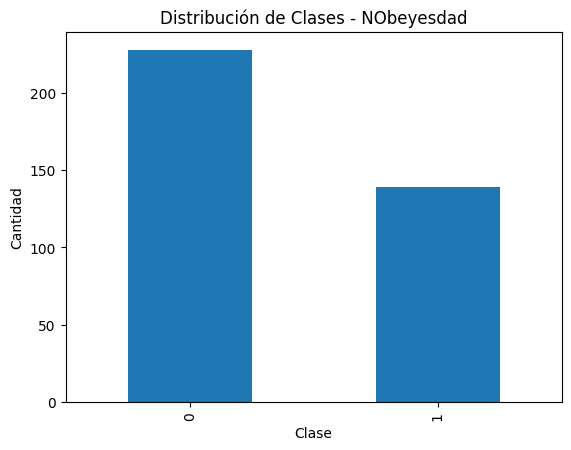

In [5]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Distribución de Clases - NObeyesdad")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

## 3.2 Balanceo

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Preprocesar SIEMPRE
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Recalcular ratio con y_train (recomendado)
conteo_train = y_train.value_counts()
ratio_train = conteo_train.max() / conteo_train.min()

print(f"Ratio train: {ratio_train:.2f}")

# Aplicar SMOTE solo si es necesario
if ratio_train >= 2:
    print("Aplicando SMOTE...")

    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_train_prep, y_train)

    print("Antes:\n", y_train.value_counts())
    print("Después:\n", pd.Series(y_train_final).value_counts())
else:
    print("No se aplica SMOTE.")
    X_train_final, y_train_final = X_train_prep, y_train

# Variable final de test (SIEMPRE igual)
X_test_final = X_test_prep

Ratio train: 1.64
No se aplica SMOTE.


# SECCIÓN 4 — Correlación y selección de Features

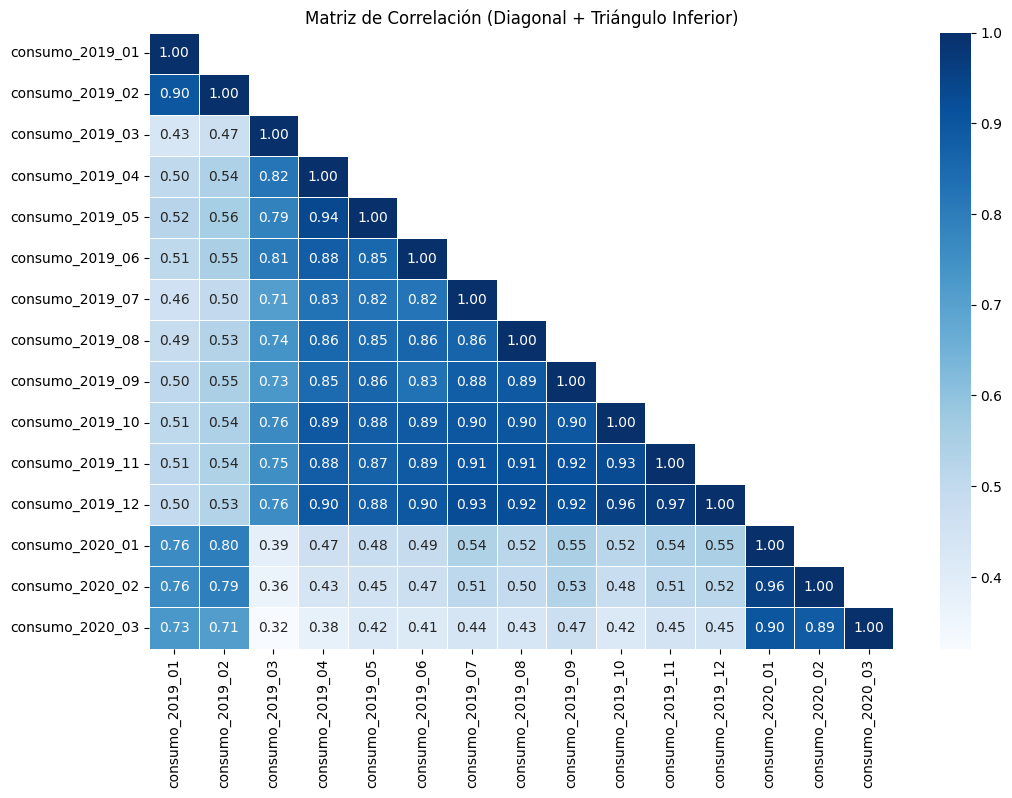

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1 deja visible la diagonal

plt.figure(figsize=(12,8))
sns.heatmap(corr, mask=mask, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación (Diagonal + Triángulo Inferior)")
plt.show()

## 4.2 Eliminar features correlacionadas > 0.85

In [8]:
threshold = 0.85

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            high_corr_pairs.append((col1, col2, corr.iloc[i, j]))

for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1} vs {col2} => Corr: {corr_val:.2f}")

consumo_2019_02 vs consumo_2019_01 => Corr: 0.90
consumo_2019_05 vs consumo_2019_04 => Corr: 0.94
consumo_2019_06 vs consumo_2019_04 => Corr: 0.88
consumo_2019_06 vs consumo_2019_05 => Corr: 0.85
consumo_2019_08 vs consumo_2019_04 => Corr: 0.86
consumo_2019_08 vs consumo_2019_06 => Corr: 0.86
consumo_2019_08 vs consumo_2019_07 => Corr: 0.86
consumo_2019_09 vs consumo_2019_05 => Corr: 0.86
consumo_2019_09 vs consumo_2019_07 => Corr: 0.88
consumo_2019_09 vs consumo_2019_08 => Corr: 0.89
consumo_2019_10 vs consumo_2019_04 => Corr: 0.89
consumo_2019_10 vs consumo_2019_05 => Corr: 0.88
consumo_2019_10 vs consumo_2019_06 => Corr: 0.89
consumo_2019_10 vs consumo_2019_07 => Corr: 0.90
consumo_2019_10 vs consumo_2019_08 => Corr: 0.90
consumo_2019_10 vs consumo_2019_09 => Corr: 0.90
consumo_2019_11 vs consumo_2019_04 => Corr: 0.88
consumo_2019_11 vs consumo_2019_05 => Corr: 0.87
consumo_2019_11 vs consumo_2019_06 => Corr: 0.89
consumo_2019_11 vs consumo_2019_07 => Corr: 0.91
consumo_2019_11 vs c

## Eliminando FAF

In [9]:
# Se utiliza en caso de que  high_corr_pairs obtenga datos para eliminar de acuerdo al porcentaje especificado
#df = df.drop("columna_a_eliminar", axis=1)

# SECCIÓN 5 — Entrenamiento y comparación de solvers

## 5.1 Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 5.2 Función entrenar_modelo(solver, C)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def entrenar_modelo(solver, C):
    modelo = LogisticRegression(
        solver=solver,
        C=C,
        max_iter=5000,
        multi_class="multinomial",
        n_jobs=-1
    )
    
    modelo.fit(X_train_final, y_train_final)
    y_pred = modelo.predict(X_test_final)
    
    acc = accuracy_score(y_test, y_pred)
    return acc

## 5.3 Comparación de solvers

In [12]:
solvers = ["lbfgs", "newton-cg", "sag", "saga"]
resultados = []

for s in solvers:
    acc = entrenar_modelo(solver=s, C=1)
    resultados.append((s, acc))

df_solvers = pd.DataFrame(resultados, columns=["Solver", "Accuracy"])
df_solvers

,Solver,Accuracy
0,lbfgs,0.81982
1,newton-cg,0.81982
2,sag,0.81982
3,saga,0.81982


### Grafico

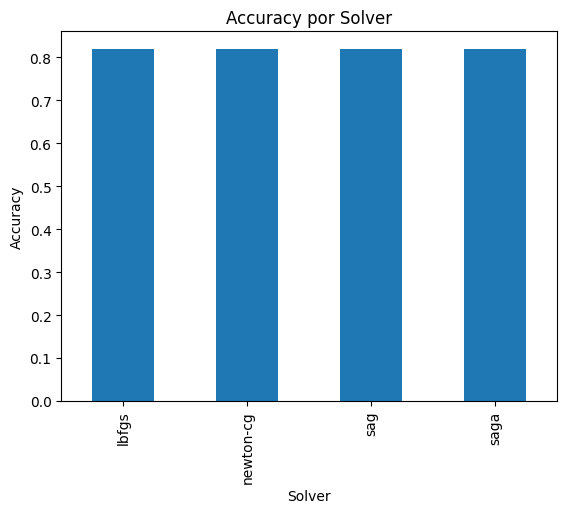

In [13]:
df_solvers.plot(x="Solver", y="Accuracy", kind="bar", legend=False)
plt.title("Accuracy por Solver")
plt.ylabel("Accuracy")
plt.show()

### Mejorar Solvers

In [14]:
mejor_solver = df_solvers.sort_values("Accuracy", ascending=False).iloc[0]["Solver"]
print("Mejor solver:", mejor_solver)

Mejor solver: lbfgs


## 5.4 Probar valores de C

In [15]:
valores_C = [0.01, 0.1, 1, 10]
resultados_C = []

for c in valores_C:
    acc = entrenar_modelo(solver=mejor_solver, C=c)
    resultados_C.append((c, acc))

df_C = pd.DataFrame(resultados_C, columns=["C", "Accuracy"])
df_C

,C,Accuracy
0,0.01,0.819820
1,0.10,0.810811
2,1.00,0.819820
3,10.00,0.810811


### Grafico

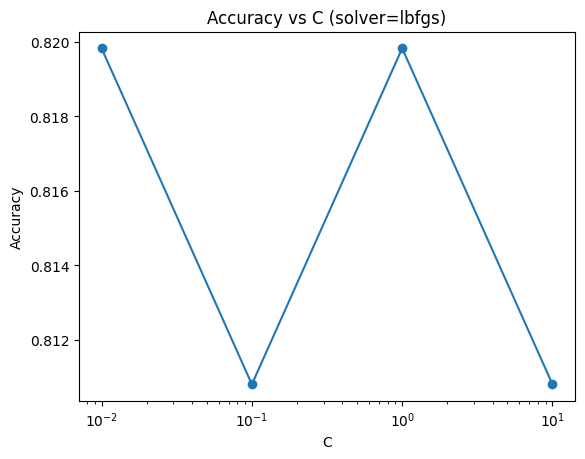

In [16]:
plt.plot(df_C["C"], df_C["Accuracy"], marker="o")
plt.xscale("log")
plt.title(f"Accuracy vs C (solver={mejor_solver})")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.show()

# SECCIÓN 6 — Evaluación e Interpretación del mejor modelo

In [17]:
mejor_C = df_C.sort_values("Accuracy", ascending=False).iloc[0]["C"]

modelo_final = LogisticRegression(
    solver=mejor_solver,
    C=mejor_C,
    max_iter=5000,
    multi_class="multinomial"
)

modelo_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_final.predict(X_test_final)

### Acurrancy Final

In [18]:
acc_final = accuracy_score(y_test, y_pred_final)
print(f"Accuracy final: {acc_final*100:.2f}%")

Accuracy final: 81.98%


### Matriz de Confusión

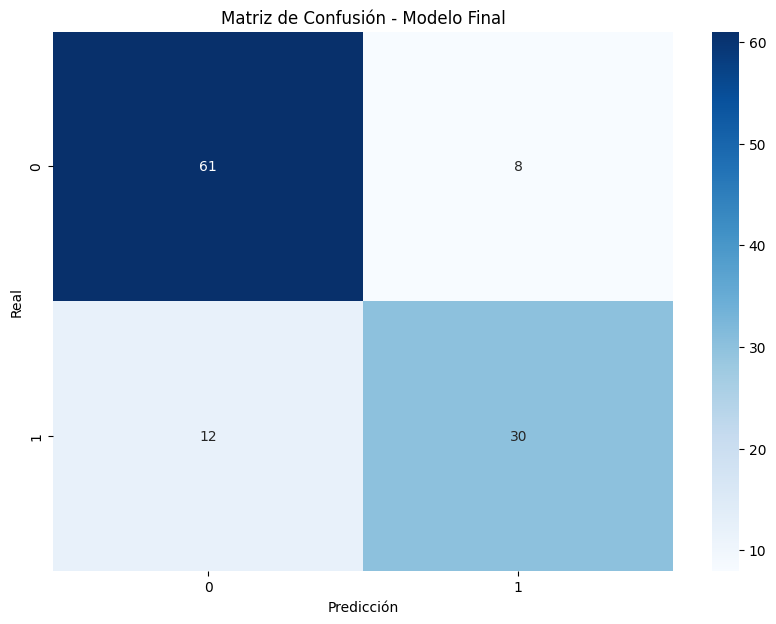

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Modelo Final")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### Reporte de clasificación

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        69
           1       0.79      0.71      0.75        42

    accuracy                           0.82       111
   macro avg       0.81      0.80      0.80       111
weighted avg       0.82      0.82      0.82       111

